In [1]:
!pip install pandas pyarrow
!pip install censusdis
!pip install pandas geopandas shapely censusdis pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.9/435.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: certifi
    Found existing installation: certifi 2025.11.12
    Uninstalling certifi-2025.11.12:
      Successfully uninstalled certifi-2025.11.12
  Attempting uninstall: pyogrio
    Found existing installation: pyogrio 0.11.1
    Uninstalling pyogrio-0.11.1:
      Successfully uninstalled pyogrio-0.11.1
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.1
    Uninstalling geopandas-

In [2]:
# -----------------------------------------
# Analisis de Datos
# Francheska Lebron
# Luis Fontan
# -----------------------------------------

In [3]:
import pandas as pd
import censusdis.data as ced

# -----------------------------------------
#Lectura data (archivo .parquet)
# -----------------------------------------

file_path = 'ccom6994_pv_dataset.parquet'
df = pd.read_parquet(file_path)
df.head()

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date
0,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-177.92735830000007 -29.246487...,505.911148,-29.246515,-177.927191,615778481436884991,19077,NaN,NaN,None
1,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,"POLYGON ((-152.7975221 -22.64438619999985, -15...",722.751608,-22.644508,-152.797387,615667837104553983,34745,NaN,NaN,None
2,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-70.9484344 -53.20046109999999...,442.152434,-53.200533,-70.948352,616420125630791679,19196,NaN,NaN,None
3,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-69.54785590000002 -52.4561568...,45.555486,-52.456164,-69.547781,616142442372005887,19206,NaN,NaN,None
4,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-62.988899400000015 -40.80502199999996),0.000000,-40.805022,-62.988899,615920622922366975,4858,NaN,NaN,None


In [38]:
import geopandas as gpd

# -----------------------------------------
# Convertir datos de placas solares (archivo .parquet) a GeoDataFrame (data mundial)
# -----------------------------------------

gdf_solar = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df["geometry"]) if df["geometry"].dtype == "object" else df["geometry"])

# -----------------------------------------
# Asegurar CRS (suponiendo WGS84)
# -----------------------------------------
gdf_solar = gdf_solar.set_crs(epsg=4326)

In [39]:
import censusdis.data as ced
import pandas as pd

# -----------------------------------------
# Definir dataset ACS y variables
# -----------------------------------------
DATASET = "acs/acs5"
PROFILE = "acs/acs5/profile"
YEAR = 2022

# Variables ACS detalladas
vars_detailed = [
    "NAME",
    "B01003_001E",   # poblacion total
    "B19013_001E",   # ingreso mediano
    "B17001_002E",   # bajo pobreza
    "B25077_001E",   # valor mediano vivienda
]

# Variables ACS Profile
vars_profile = [
    "DP03_0009PE",   # % desempleo
    "DP02_0068PE",   # % bachillerato o más
    "DP05_0071PE",   # % hispano
]



In [40]:
# -----------------------------------------
# Descargar data (solo California)
# -----------------------------------------
gdf_prof = ced.download(
    PROFILE,
    YEAR,
    vars_profile,
    state="06",
    county="*",
    with_geometry=False
)

gdf_det = ced.download(
    DATASET,
    YEAR,
    vars_detailed,
    state="06",      # California
    county="*",
    with_geometry=True
)

# Renombrar geometría
gdf_det = gdf_det.rename(columns={"geometry": "geometry_census"})
gdf_det = gdf_det.set_geometry("geometry_census")


gdf_det.columns


Index(['STATE', 'COUNTY', 'NAME', 'B01003_001E', 'B19013_001E', 'B17001_002E',
       'B25077_001E', 'geometry_census'],
      dtype='object')

In [41]:

# -----------------------------------------
# Unir ambas tablas
# -----------------------------------------
gdf = gdf_det.merge(
    gdf_prof,
    on=["STATE", "COUNTY"],
    how="left"
)

# -----------------------------------------
# Renombrar columnas
# -----------------------------------------
gdf = gdf.rename(columns={
    "B01003_001E": "poblacion_total",
    "B19013_001E": "ingreso_medio_hogar",
    "B17001_002E": "poblacion_bajo_pobreza",
    "B25077_001E": "valor_medio_vivienda",
    "DP03_0009PE": "porc_desempleo",
    "DP02_0068PE": "porc_educ_bachillerato",
    "DP05_0071PE": "porc_hispano"
})

# -----------------------------------------
# Asegurar CRS
# -----------------------------------------
gdf = gdf.set_crs(epsg=4269).to_crs(epsg=4326)

gdf.head()


,STATE,COUNTY,NAME,poblacion_total,ingreso_medio_hogar,poblacion_bajo_pobreza,valor_medio_vivienda,geometry_census,porc_desempleo,porc_educ_bachillerato,porc_hispano
0,06,001,"Alameda County, California",1663823,122488,149843,999200,"POLYGON ((-122.34225 37.80556, -122.33385 37.8...",4.9,50.9,16.9
1,06,003,"Alpine County, California",1515,101125,208,463900,"POLYGON ((-120.07239 38.70277, -120.06762 38.7...",4.9,39.6,7.8
2,06,005,"Amador County, California",40577,74853,2945,409600,"POLYGON ((-121.02741 38.50354, -121.02747 38.5...",6.0,20.6,10.5
3,06,007,"Butte County, California",213605,66085,38015,371600,"POLYGON ((-122.06874 39.84222, -122.06694 39.8...",7.1,30.8,10.6
4,06,009,"Calaveras County, California",45674,77526,5915,404200,"POLYGON ((-120.9936 38.22558, -120.99161 38.22...",6.2,21.4,8.4


In [42]:
from shapely.geometry import Point

#hacer Join de Datos de Placas Solares y del Censo
gdf_points = gdf_solar.copy()
gdf_points["geometry"] = [
    Point(lon, lat)
    for lon, lat in zip(gdf_points["centroid_lon"], gdf_points["centroid_lat"])
]
gdf_points = gdf_points.set_crs(epsg=4326)

gdf_california = gpd.sjoin(
    gdf_points,
    gdf,
    how="left",
    predicate="within"   # cada punto cae dentro de un county
)


gdf_california

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,...,STATE,COUNTY,NAME,poblacion_total,ingreso_medio_hogar,poblacion_bajo_pobreza,valor_medio_vivienda,porc_desempleo,porc_educ_bachillerato,porc_hispano
0,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-177.92719 -29.24651),505.911148,-29.246515,-177.927191,615778481436884991,19077,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-152.79739 -22.64451),722.751608,-22.644508,-152.797387,615667837104553983,34745,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-70.94835 -53.20053),442.152434,-53.200533,-70.948352,616420125630791679,19196,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-69.54778 -52.45616),45.555486,-52.456164,-69.547781,616142442372005887,19206,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-62.9889 -40.80502),0.000000,-40.805022,-62.988899,615920622922366975,4858,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443742,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (143.89265 -39.93811),732.052270,-39.938106,143.892652,616299517211312127,19221,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443743,global_pv_inventory_sent2_spot_2021,2025-09-26 03:24:11.103000+00:00,POINT (146.55166 -38.17957),20987.479133,-38.179572,146.551657,615838840094982143,465.0,12968.531637,1.119601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443744,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (148.06426 -42.58429),77.507376,-42.584288,148.064258,615854879845384191,35203,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
443745,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (147.50307 -42.86353),25.670090,-42.863530,147.503067,615854925817053183,19219,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
gdf_california_full = gdf_california[gdf_california["STATE"] == "06"].copy()


In [44]:
len(gdf_california_full.geometry)

25287

In [45]:
#Contar cantidad de placas solares por County
conteo = (
    gdf_california_full
    .groupby(["STATE", "COUNTY"], as_index=False)
    .size()
    .rename(columns={"size": "n_plantas"})
)

# unir conteo a gdf_census, que SÍ tiene la geometría de county
gdf_california_full = gdf.merge(
    conteo,
    on=["STATE", "COUNTY"],
    how="left"
).fillna({"n_plantas": 0})


In [47]:
# Proyectar counties a CRS adecuado para área en California
gdf_california_full = gdf_california_full.to_crs(epsg=3310)

# Calcular área del county en km²
gdf_california_full["area_km2"] = gdf_california_full.geometry.area / 1_000_000

# Calcular densidad de plantas solares
gdf_california_full["densidad_solar"] = (
    gdf_california_full["n_plantas"] / gdf_california_full["area_km2"]
)

# Variable binaria: presencia o ausencia de plantas solares
gdf_california_full["tiene_solar"] = (gdf_california_full["n_plantas"] > 0).astype(int)


In [49]:
gdf_california_full.head()
gdf_california_full.shape

(58, 15)

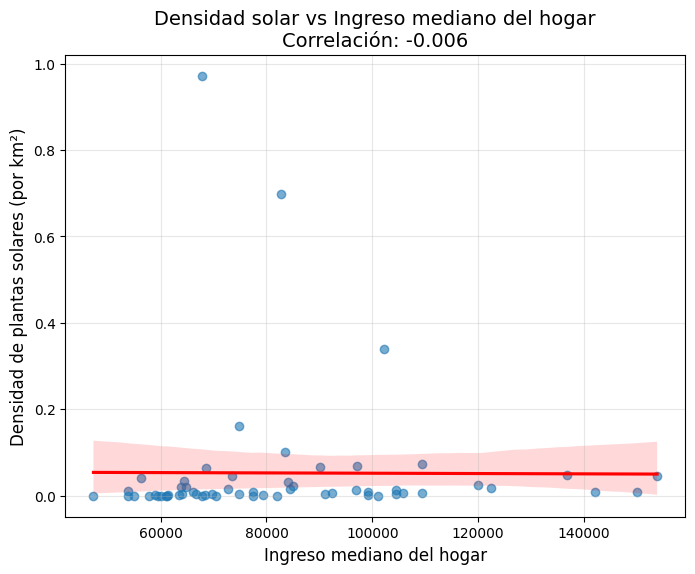

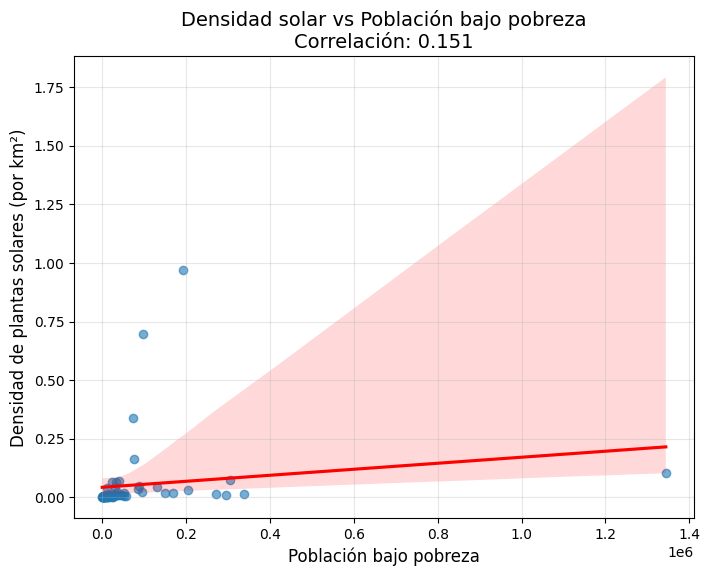

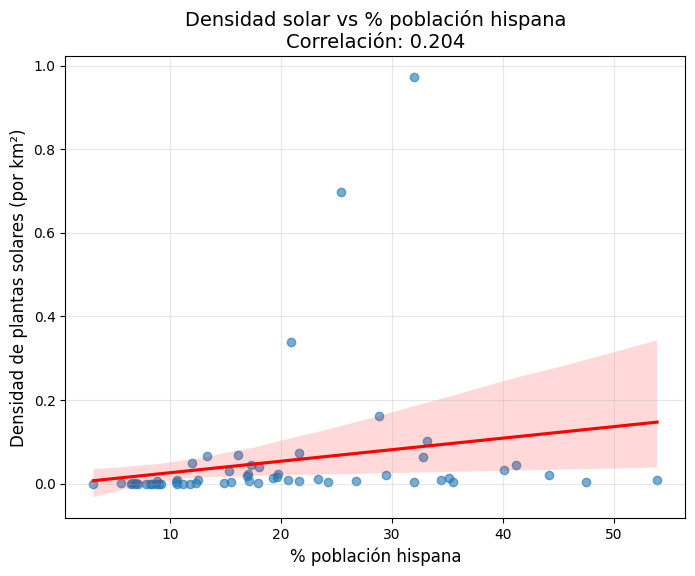

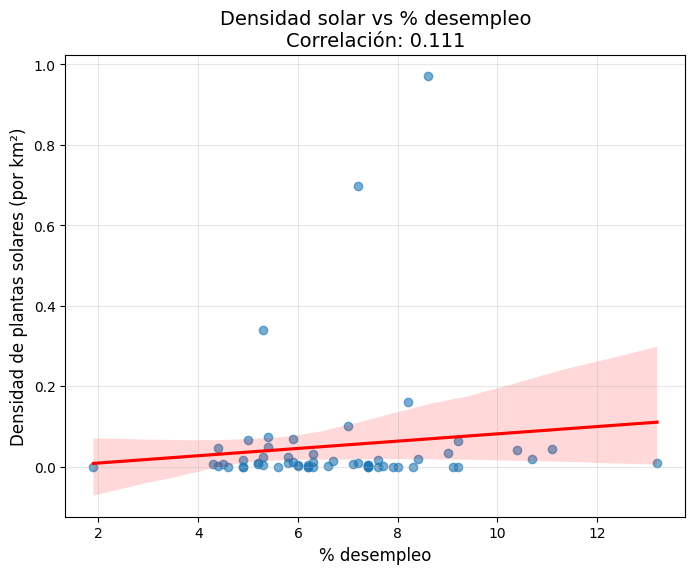

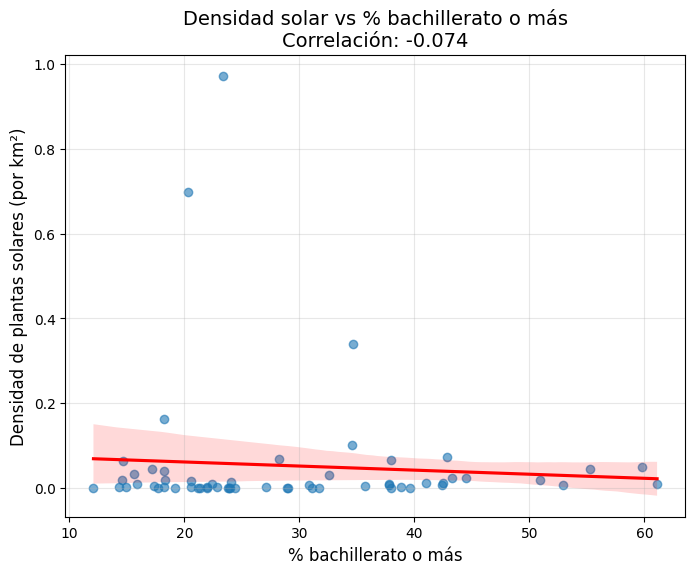

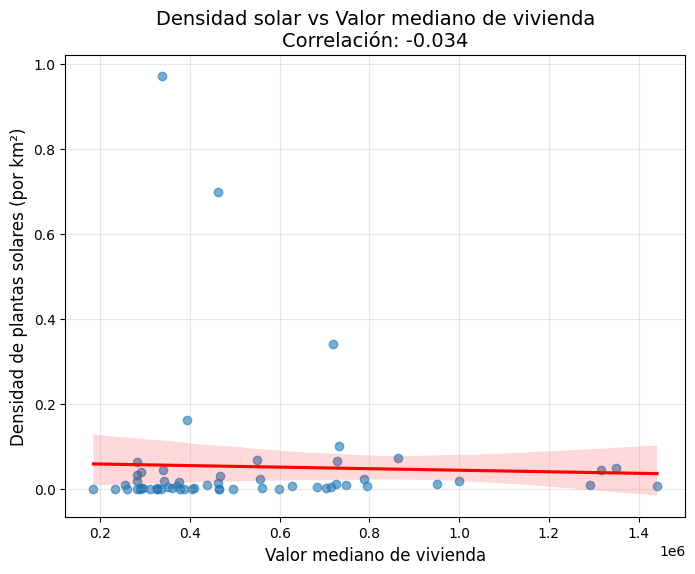

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
vars_to_plot = [
    ("ingreso_medio_hogar", "Ingreso mediano del hogar"),
    ("poblacion_bajo_pobreza", "Población bajo pobreza"),
    ("porc_hispano", "% población hispana"),
    ("porc_desempleo", "% desempleo"),
    ("porc_educ_bachillerato", "% bachillerato o más"),
    ("valor_medio_vivienda", "Valor mediano de vivienda"),
]


import numpy as np

for var, label in vars_to_plot:
    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=gdf_california_full,
        x=var,
        y="densidad_solar",
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )

    # Correlación Pearson
    corr = gdf_california_full[[var, "densidad_solar"]].corr().iloc[0, 1]

    plt.title(f"Densidad solar vs {label}\nCorrelación: {corr:.3f}", fontsize=14)
    plt.xlabel(label, fontsize=12)
    plt.ylabel("Densidad de plantas solares (por km²)", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()
